In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, SimpleRNN
from sklearn.preprocessing import MinMaxScaler


2025-09-27 10:41:10.683966: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758969670.981973      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758969671.071374      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Detected Date column: date
Detected Close column: adjClose


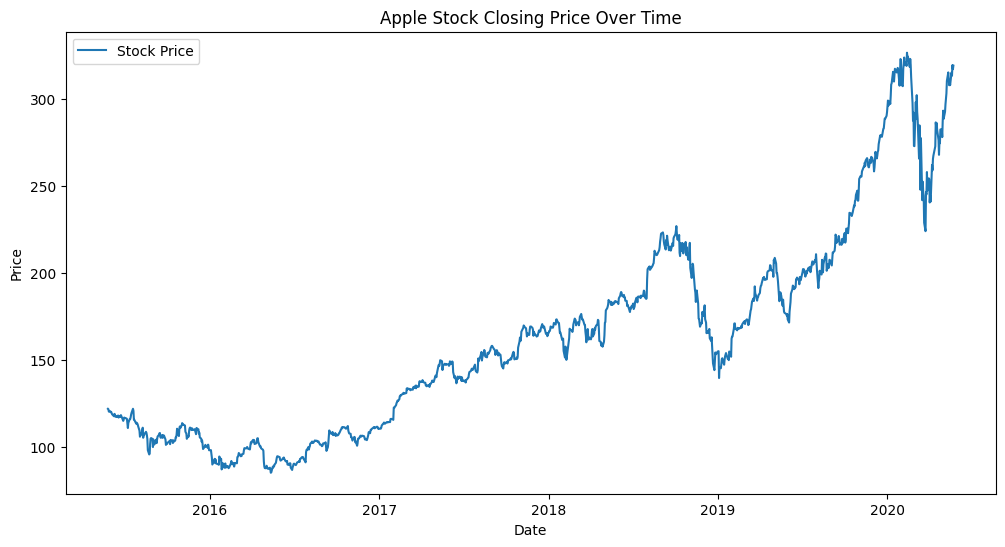

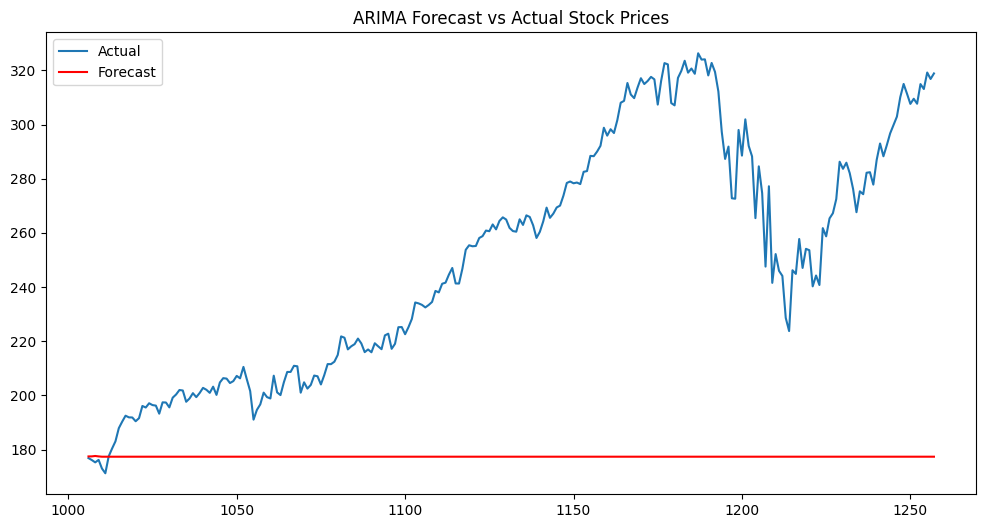

Mean Squared Error: 7252.680014766559
Root Mean Squared Error: 85.1626679641177
Forecast results saved as apple_stock_forecast.csv


In [4]:
# Project 5: Time Series Forecasting for Stock Prices (Apple Example)

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# Step 1: Load dataset (adjust path if needed on Kaggle)
df = pd.read_csv("/kaggle/input/applestock/AAPL.csv")

# Step 2: Detect Date and Close column names
date_col = None
close_col = None

for col in df.columns:
    if "date" in col.lower() or "time" in col.lower():
        date_col = col
    if "close" in col.lower():
        close_col = col

print("Detected Date column:", date_col)
print("Detected Close column:", close_col)

# Step 3: Prepare dataframe
df[date_col] = pd.to_datetime(df[date_col])
df = df[[date_col, close_col]].dropna()
df = df.sort_values(by=date_col)

# Step 4: Plot stock closing prices
plt.figure(figsize=(12,6))
plt.plot(df[date_col], df[close_col], label="Stock Price")
plt.title("Apple Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# Step 5: Train-Test Split (80-20)
train_size = int(len(df) * 0.8)
train, test = df[close_col][:train_size], df[close_col][train_size:]

# Step 6: ARIMA Model Training
model = ARIMA(train, order=(5,1,0))  # (p,d,q)
model_fit = model.fit()

# Step 7: Forecasting
forecast = model_fit.forecast(steps=len(test))

# Step 8: Plot predictions vs actual
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast", color="red")
plt.title("ARIMA Forecast vs Actual Stock Prices")
plt.legend()
plt.show()

# Step 9: Evaluate model
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

output = pd.DataFrame({"Date": test.index, "Actual": test.values, "Predicted": forecast.values})
output.to_csv("apple_stock_forecast.csv", index=False)
print("Forecast results saved as apple_stock_forecast.csv")
